# HR Analytics Pipeline
**Author:** Abdalla | **Dataset:** IBM HR Attrition (1,470 employees) | **Stack:** Python, Pandas, SQL, Power BI

## Week 1 — Load & Explore
Loading raw data, examining structure, and understanding key attrition patterns through exploratory analysis.

### Load and Inspect Dataset
Read the HR dataset and display its basic structure, shape, and column names to understand what we're working with.

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition (1).csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Shape: (1470, 35)

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction Standard

### Explore Attrition Patterns
Calculate attrition rates across different employee groups (departments, gender, overtime status, travel frequency, and marital status) to identify which demographics have highest turnover.

In [2]:
# Q1: How many employees left vs stayed?
print("── Attrition Count ──")
print(df["Attrition"].value_counts())

# Q2: Attrition rate in %
print("\n── Attrition Rate ──")
print((df["Attrition"].value_counts(normalize=True) * 100).round(2))

# Q3: Average employee age
print("\n── Average Age ──")
print(df["Age"].mean().round(1))

# Q4: Which department has the most attrition?
print("\n── Attrition by Department ──")
print(df[df["Attrition"] == "Yes"]["Department"].value_counts())

# Q5: Average monthly income by job role
print("\n── Avg Monthly Income by Job Role ──")
print(df.groupby("JobRole")["MonthlyIncome"].mean().round(0).sort_values(ascending=False))

── Attrition Count ──
Attrition
No     1233
Yes     237
Name: count, dtype: int64

── Attrition Rate ──
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

── Average Age ──
36.9

── Attrition by Department ──
Department
Research & Development    133
Sales                      92
Human Resources            12
Name: count, dtype: int64

── Avg Monthly Income by Job Role ──
JobRole
Manager                      17182.0
Research Director            16034.0
Healthcare Representative     7529.0
Manufacturing Director        7295.0
Sales Executive               6924.0
Human Resources               4236.0
Research Scientist            3240.0
Laboratory Technician         3237.0
Sales Representative          2626.0
Name: MonthlyIncome, dtype: float64


### Summary Statistics and Initial KPIs
Generate descriptive statistics for numeric columns and save summary outputs to CSV for later reference.

In [3]:
# ── Summary Stats & Saving Output ────────────────────────────────────

# Full statistical summary of all numeric columns
print("── Dataset Summary ──")
print(df.describe().round(1))

# Summary of just the key columns we care about
print("\n── Key Columns Summary ──")
key_cols = ["Age", "MonthlyIncome", "YearsAtCompany", "JobSatisfaction", "WorkLifeBalance"]
print(df[key_cols].describe().round(1))

# Save the key summary to a CSV file
df[key_cols].describe().round(1).to_csv("summary_stats.csv")
print("\n✅ summary_stats.csv saved!")

# Save the attrition counts to CSV
df["Attrition"].value_counts().to_csv("attrition_count.csv")
print("✅ attrition_count.csv saved!")

── Dataset Summary ──
          Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
count  1470.0     1470.0            1470.0     1470.0         1470.0   
mean     36.9      802.5               9.2        2.9            1.0   
std       9.1      403.5               8.1        1.0            0.0   
min      18.0      102.0               1.0        1.0            1.0   
25%      30.0      465.0               2.0        2.0            1.0   
50%      36.0      802.0               7.0        3.0            1.0   
75%      43.0     1157.0              14.0        4.0            1.0   
max      60.0     1499.0              29.0        5.0            1.0   

       EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
count          1470.0                   1470.0      1470.0          1470.0   
mean           1024.9                      2.7        65.9             2.7   
std             602.0                      1.1        20.3             0.7   
min              

### Data Quality Checks
Verify dataset integrity by checking for missing values, duplicates, data types, and columns with single unique values (which would be useless for analysis).

In [4]:
# ── Data Quality Check ────────────────────────────────────────────────

# Check 1: Any missing values?
print("── Missing Values Per Column ──")
print(df.isnull().sum())

# Check 2: Any duplicate rows?
print("\n── Duplicate Rows ──")
print(df.duplicated().sum())

# Check 3: Data types of each column
print("\n── Column Data Types ──")
print(df.dtypes)

# Check 4: Columns that have only ONE unique value (useless for analysis)
print("\n── Columns With Only 1 Unique Value ──")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"  {col} → always: {df[col].unique()[0]}")

── Missing Values Per Column ──
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

### Categorical Exploration
Identify numeric vs text columns and examine unique values within each categorical column to understand data diversity.

In [5]:
# ── Exploring Categorical Columns ─────────────────────────────────────

# First, separate numeric and text columns automatically
numeric_cols = df.select_dtypes(include="number").columns.tolist()
text_cols = df.select_dtypes(include="object").columns.tolist()

print("── Numeric Columns ──")
print(numeric_cols)

print("\n── Text (Categorical) Columns ──")
print(text_cols)

# Now explore each text column — how many unique values and what are they?
print("\n── Unique Values Per Text Column ──")
for col in text_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().to_string())

── Numeric Columns ──
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

── Text (Categorical) Columns ──
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

── Unique Values Per Text Column ──

Attrition (2 unique):
Attrition
No     1233
Yes     237

BusinessTravel (3 unique):
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150

Department (3 unique):
Department
Research & Development    961
Sales                     446
Human Resource

C:\Users\Abdul\AppData\Local\Temp\ipykernel_35308\402870134.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns.tolist()


### Calculate Attrition Rates by Demographics  
Create a numeric version of Attrition for math operations, then calculate turnover rates for each demographic group (department, gender, overtime, travel, marital status).

In [6]:
# ── Attrition Rate by Group ──────────────────────────────────────────

# wecreate a numeric version of Attrition (Yes=1, No=0)
# This lets us calculate rates using math
df["Attrition_Num"] = (df["Attrition"] == "Yes").astype(int)

# Function to calculate attrition rate for any column
def attrition_rate(col):
    result = df.groupby(col)["Attrition_Num"].mean() * 100
    return result.round(1).sort_values(ascending=False)

# Q1: Attrition rate by Department
print("── By Department ──")
print(attrition_rate("Department"))

# Q2: Attrition rate by Gender
print("\n── By Gender ──")
print(attrition_rate("Gender"))

# Q3: Attrition rate by OverTime
print("\n── By OverTime ──")
print(attrition_rate("OverTime"))

# Q4: Attrition rate by BusinessTravel
print("\n── By BusinessTravel ──")
print(attrition_rate("BusinessTravel"))

# Q5: Attrition rate by MaritalStatus
print("\n── By MaritalStatus ──")
print(attrition_rate("MaritalStatus"))

── By Department ──
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition_Num, dtype: float64

── By Gender ──
Gender
Male      17.0
Female    14.8
Name: Attrition_Num, dtype: float64

── By OverTime ──
OverTime
Yes    30.5
No     10.4
Name: Attrition_Num, dtype: float64

── By BusinessTravel ──
BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0
Name: Attrition_Num, dtype: float64

── By MaritalStatus ──
MaritalStatus
Single      25.5
Married     12.5
Divorced    10.1
Name: Attrition_Num, dtype: float64


### Key Attrition Rate Insights
Display attrition rates grouped by major categorical features to identify which groups have highest turnover.

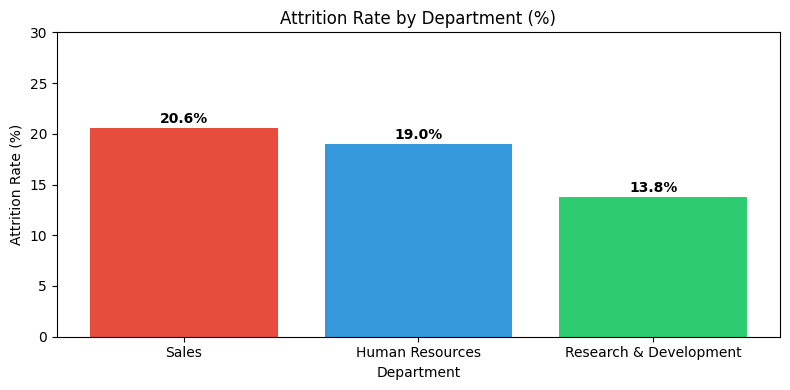

 Chart saved!


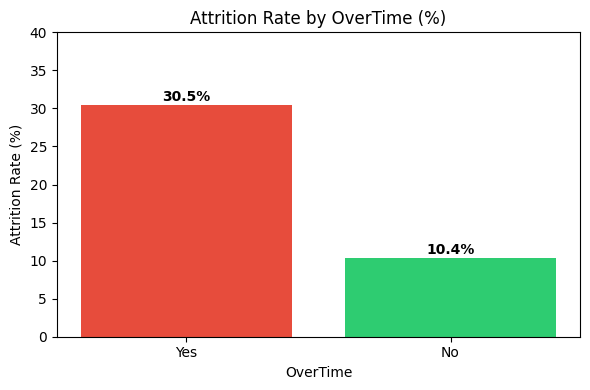

Chart saved!


In [7]:
# ── Visualizing Attrition ─────────────────────────────────────────────

import matplotlib.pyplot as plt

# Chart 1: Attrition Rate by Department
dept_rate = attrition_rate("Department")

plt.figure(figsize=(8, 4))
plt.bar(dept_rate.index, dept_rate.values, color=["#e74c3c", "#3498db", "#2ecc71"])
plt.title("Attrition Rate by Department (%)")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 30)
for i, v in enumerate(dept_rate.values):
    plt.text(i, v + 0.5, f"{v}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("attrition_by_department.png")
plt.show()
print(" Chart saved!")

# Chart 2: Attrition Rate by OverTime
ot_rate = attrition_rate("OverTime")

plt.figure(figsize=(6, 4))
plt.bar(ot_rate.index, ot_rate.values, color=["#e74c3c", "#2ecc71"])
plt.title("Attrition Rate by OverTime (%)")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 40)
for i, v in enumerate(ot_rate.values):
    plt.text(i, v + 0.5, f"{v}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("attrition_by_overtime.png")
plt.show()
print("Chart saved!")

### Visualize Key Attrition Patterns
Create bar charts showing attrition rates by department and overtime status, plus histograms comparing age and income between employees who stayed vs left.

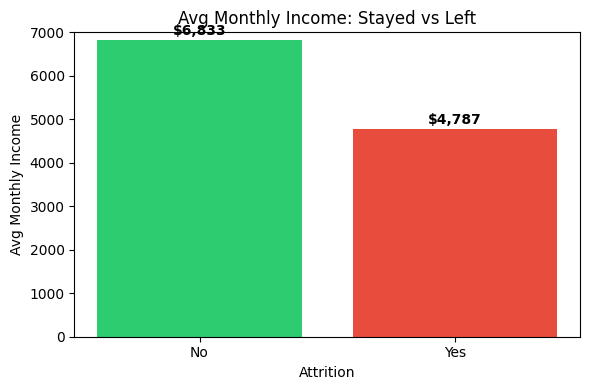

 Chart saved!


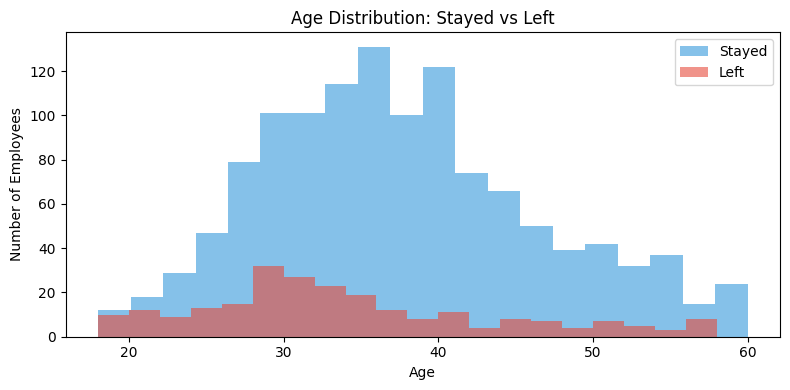

 Chart saved!


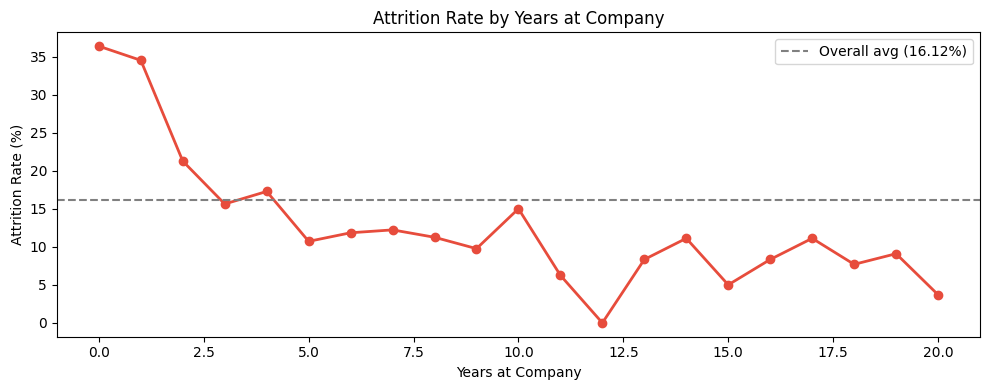

 Chart saved!


In [8]:
# ──  More Charts ───────────────────────────────────────────────────────

# Chart 3: Average Monthly Income — Attrition Yes vs No
income_by_attrition = df.groupby("Attrition")["MonthlyIncome"].mean().round(0)

plt.figure(figsize=(6, 4))
plt.bar(income_by_attrition.index, income_by_attrition.values, color=["#2ecc71", "#e74c3c"])
plt.title("Avg Monthly Income: Stayed vs Left")
plt.xlabel("Attrition")
plt.ylabel("Avg Monthly Income")
plt.ylim(0, 7000)
for i, v in enumerate(income_by_attrition.values):
    plt.text(i, v + 100, f"${v:,.0f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("income_vs_attrition.png")
plt.show()
print(" Chart saved!")

# Chart 4: Age Distribution — Stayed vs Left
stayed = df[df["Attrition"] == "No"]["Age"]
left = df[df["Attrition"] == "Yes"]["Age"]

plt.figure(figsize=(8, 4))
plt.hist(stayed, bins=20, alpha=0.6, color="#3498db", label="Stayed")
plt.hist(left, bins=20, alpha=0.6, color="#e74c3c", label="Left")
plt.title("Age Distribution: Stayed vs Left")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.legend()
plt.tight_layout()
plt.savefig("age_distribution.png")
plt.show()
print(" Chart saved!")

# Chart 5: Attrition Rate by Years at Company (first 20 years)
years_rate = df[df["YearsAtCompany"] <= 20].groupby("YearsAtCompany")["Attrition_Num"].mean() * 100

plt.figure(figsize=(10, 4))
plt.plot(years_rate.index, years_rate.values, color="#e74c3c", marker="o", linewidth=2)
plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.axhline(y=16.12, color="gray", linestyle="--", label="Overall avg (16.12%)")
plt.legend()
plt.tight_layout()
plt.savefig("attrition_by_tenure.png")
plt.show()
print(" Chart saved!")

> **Finding:** Attrition is concentrated in specific groups: **Sales (20.6%)**, **Overtime workers (30.5%)**, and **Single employees (25.5%)** all show significantly higher turnover than the overall 16.12% rate. New employees (0-1 year) have substantially higher attrition.

### Additional Exploratory Charts
Generate comparative visualizations for income, age distribution, and tenure patterns to surface attrition drivers.

## Week 2 — Data Cleaning
Removing useless columns, encoding categorical variables, and preparing data for analysis.

### Drop Useless Columns and Rename
Remove uninformative columns (EmployeeCount, Over18, StandardHours, EmployeeNumber) that add no analytical value, and rename Attrition_Num to Attrition_Flag for clarity.

In [9]:
# ── Cleaning — Drop & Rename ──────────────────────────────────

#  Make a copy of the original 
df_clean = df.copy()
print(f"Original shape: {df_clean.shape}")

#  Drop the 3 useless columns 
useless_cols = ["EmployeeCount", "Over18", "StandardHours"]
df_clean = df_clean.drop(columns=useless_cols)
print(f"After dropping useless columns: {df_clean.shape}")

#  drop EmployeeNumber — 
df_clean = df_clean.drop(columns=["EmployeeNumber"])
print(f"After dropping ID column: {df_clean.shape}")

# Rename Attrition_Num
df_clean = df_clean.rename(columns={"Attrition_Num": "Attrition_Flag"})

# Confirm the columns that remain
print(f"\nRemaining columns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())

Original shape: (1470, 36)
After dropping useless columns: (1470, 33)
After dropping ID column: (1470, 32)

Remaining columns (32):
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Flag']


### Encode Text Columns to Numbers
Convert categorical text columns (Gender, OverTime, BusinessTravel) into numeric codes for compatibility with machine learning and analysis algorithms.

In [10]:
# ── Encoding Text Columns ─────────────────────────────────────

# Convert simple Yes/No columns to 1/0
yes_no_cols = ["OverTime"]
for col in yes_no_cols:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0})
    print(f" {col} encoded")

#  Convert Gender to 1/0
df_clean["Gender"] = df_clean["Gender"].map({"Male": 1, "Female": 0})
print(" Gender encoded (Male=1, Female=0)")

# Convert BusinessTravel to ordered numbers
# Non-Travel=0, Travel_Rarely=1, Travel_Frequently=2
travel_map = {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
df_clean["BusinessTravel"] = df_clean["BusinessTravel"].map(travel_map)
print(" BusinessTravel encoded (Non-Travel=0, Rarely=1, Frequently=2)")

#  Confirm no more Yes/No text remains in these columns
print("\n── Sample of encoded columns ──")
print(df_clean[["OverTime", "Gender", "BusinessTravel", "Attrition_Flag"]].head(10))

 OverTime encoded
 Gender encoded (Male=1, Female=0)
 BusinessTravel encoded (Non-Travel=0, Rarely=1, Frequently=2)

── Sample of encoded columns ──
   OverTime  Gender  BusinessTravel  Attrition_Flag
0         1       0               1               1
1         0       1               2               0
2         1       1               1               1
3         1       0               2               0
4         0       1               1               0
5         0       1               2               0
6         1       0               1               0
7         0       1               1               0
8         0       1               2               0
9         0       1               1               0


### Optimize Data Types  
Convert multi-value categorical columns (Education, JobSatisfaction, WorkLifeBalance, etc.) to pandas category type to reduce memory usage and improve performance.

In [11]:
# ──Fixing Data Types ─────────────────────────────────────────

#  Check current data types
print("── Current Data Types ──")
print(df_clean.dtypes)

# These columns look like numbers but are actually categories
# 1=Low 2=Medium 3=High 4=Very High
category_cols = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

# Convert them to pandas "category" type
for col in category_cols:
    df_clean[col] = df_clean[col].astype("category")
    print(f" {col} → category")

# Confirm the changes
print("\n── Updated Data Types (sample) ──")
print(df_clean[category_cols].dtypes)

#Check memory improvement
print(f"\n── Memory Usage ──")
print(f"use category type for low-unique columns")
print(df_clean.memory_usage(deep=True).sum() / 1024, "KB")

── Current Data Types ──
Age                         int64
Attrition                     str
BusinessTravel              int64
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole     

### Create Processing Directory and Save Clean Dataset
Set up the processed data folder and export the cleaned dataset to CSV for downstream processing.

In [12]:
import os
os.makedirs("data/processed", exist_ok=True)

### Verify Dataset Reload
Confirm that the saved clean dataset can be read back correctly and check data types.

In [13]:
#  Save clean dataset to CSV

output_path = "data/processed/df_clean.csv"

df_clean.to_csv(output_path, index=False)

print(f" Clean dataset saved to: {output_path}")
print(f"   Shape: {df_clean.shape}")
print(f"   Columns: {df_clean.columns.tolist()}")

 Clean dataset saved to: data/processed/df_clean.csv
   Shape: (1470, 32)
   Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Flag']


### Select Continuous Columns for Normalization
Identify numeric columns that need scaling to 0-1 range (excluding binary and categorical columns).

In [14]:
# Load it back and check
df_verify = pd.read_csv("data/processed/df_clean.csv")
print(f"Reload check — Shape: {df_verify.shape}")
print(df_verify.dtypes)

Reload check — Shape: (1470, 32)
Age                         int64
Attrition                     str
BusinessTravel              int64
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentR

## Week 2 (cont.) — Normalization & Feature Engineering
Scaling numeric features to 0-1 range and creating new derived features to enhance analytical insights.

In [15]:
# We only normalize continuous numeric columns
# NOT binary (0/1) columns, NOT category columns

cols_to_normalize = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

print(f"Columns to normalize: {len(cols_to_normalize)}")
print(df_clean[cols_to_normalize].describe().round(2))

Columns to normalize: 14
           Age  DailyRate  DistanceFromHome  HourlyRate  MonthlyIncome  \
count  1470.00    1470.00           1470.00     1470.00        1470.00   
mean     36.92     802.49              9.19       65.89        6502.93   
std       9.14     403.51              8.11       20.33        4707.96   
min      18.00     102.00              1.00       30.00        1009.00   
25%      30.00     465.00              2.00       48.00        2911.00   
50%      36.00     802.00              7.00       66.00        4919.00   
75%      43.00    1157.00             14.00       83.75        8379.00   
max      60.00    1499.00             29.00      100.00       19999.00   

       MonthlyRate  NumCompaniesWorked  PercentSalaryHike  TotalWorkingYears  \
count      1470.00             1470.00            1470.00            1470.00   
mean      14313.10                2.69              15.21              11.28   
std        7117.79                2.50               3.66           

### Apply MinMax Scaling
Transform all continuous numeric columns to 0-1 scale using scikit-learn's MinMaxScaler, preventing high-magnitude features from dominating analysis.

In [16]:
import subprocess
result = subprocess.run(
    ["uv", "pip", "install", "scikit-learn", "--system"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)


Using Python 3.14.4 environment at: C:\Users\Abdul\AppData\Local\Python\pythoncore-3.14-64
Checked 1 package in 3.31s



In [17]:
%pip install scikit-learn -q --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = df_clean.copy()
df_normalized[cols_to_normalize] = scaler.fit_transform(df_clean[cols_to_normalize])

print("Before — MonthlyIncome range:")
print(f"  min: {df_clean['MonthlyIncome'].min()}, max: {df_clean['MonthlyIncome'].max()}")

print("\nAfter — MonthlyIncome range:")
print(f"  min: {df_normalized['MonthlyIncome'].min():.4f}, max: {df_normalized['MonthlyIncome'].max():.4f}")

Before — MonthlyIncome range:
  min: 1009, max: 19999

After — MonthlyIncome range:
  min: 0.0000, max: 1.0000


### Visualize Normalization Effect
Create side-by-side histograms showing how MinMax scaling transforms the MonthlyIncome distribution.

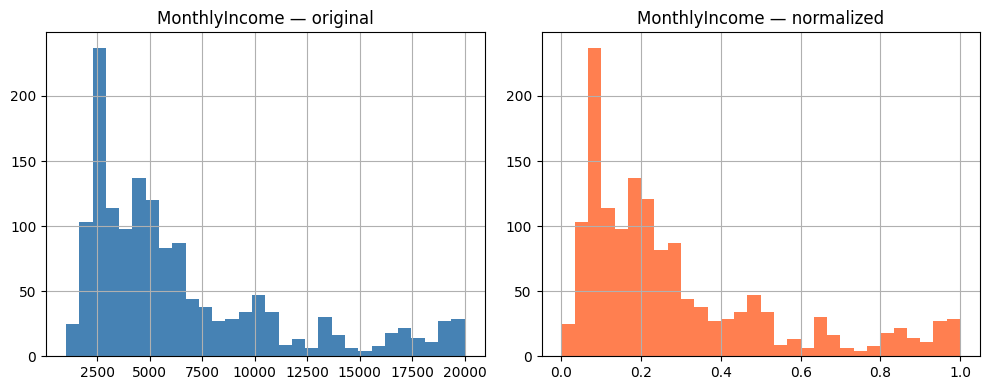

Chart saved


In [19]:
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_clean['MonthlyIncome'].hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('MonthlyIncome — original')

df_normalized['MonthlyIncome'].hist(ax=axes[1], bins=30, color='coral')
axes[1].set_title('MonthlyIncome — normalized')

plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/normalization_check.png', dpi=150)
plt.show()
print("Chart saved")

### Save Normalized Dataset
Export the normalized dataset to CSV for feature engineering and further analysis.

In [20]:
df_normalized.to_csv("data/processed/df_normalized.csv", index=False)
print("Saved df_normalized")

Saved df_normalized


### Create New Features
Engineer three business-relevant features: IncomePerYear (annual salary), TenureRoleRatio (role stability), and SeniorityScore (career advancement).

### Feature Engineering
Create 3 new derived features capturing business insights: annual income, role tenure ratio, and seniority score.

In [21]:
df_engineered = df_normalized.copy()

# Annual income (more business-friendly than monthly)
df_engineered['IncomePerYear'] = df_engineered['MonthlyIncome'] * 12

# Role tenure ratio — how long in same role vs total company tenure
# Add small number to avoid division by zero (some employees have 0 years)
df_engineered['TenureRoleRatio'] = (
    df_engineered['YearsInCurrentRole'] / (df_engineered['YearsAtCompany'] + 0.1)
)

# Seniority score — level × experience combined
df_engineered['SeniorityScore'] = (
    df_engineered['JobLevel'] * df_engineered['TotalWorkingYears']
)

print(f"New shape: {df_engineered.shape}")
print("\nNew columns preview:")
print(df_engineered[['IncomePerYear', 'TenureRoleRatio', 'SeniorityScore']].head(10))

New shape: (1470, 35)

New columns preview:
   IncomePerYear  TenureRoleRatio  SeniorityScore
0       3.149447         0.888889           0.400
1       2.604107         1.111111           0.500
2       0.683096         0.000000           0.175
3       1.200632         1.296296           0.200
4       1.553870         0.740741           0.150
5       1.301106         1.414141           0.200
6       1.049605         0.000000           0.300
7       1.064139         0.000000           0.025
8       5.381991         1.196581           0.750
9       2.671722         1.414141           0.850


### Analyze New Features by Attrition
Compare engineered feature values between employees who left vs stayed to validate their predictive power.

In [22]:
print("Avg TenureRoleRatio by attrition:")
print(df_engineered.groupby('Attrition_Flag')['TenureRoleRatio'].mean().round(3))

print("\nAvg SeniorityScore by attrition:")
print(df_engineered.groupby('Attrition_Flag')['SeniorityScore'].mean().round(3))

Avg TenureRoleRatio by attrition:
Attrition_Flag
0    0.784
1    0.565
Name: TenureRoleRatio, dtype: float64

Avg SeniorityScore by attrition:
Attrition_Flag
0    0.806
1    0.462
Name: SeniorityScore, dtype: float64


### Save Engineered Dataset
Export the feature-enhanced dataset to CSV for database loading and advanced analysis.

In [23]:
df_engineered.to_csv("data/processed/df_engineered.csv", index=False)
print(f"Saved Shape: {df_engineered.shape}")

Saved Shape: (1470, 35)


> **Finding:** New engineered features reveal strong attrition signals. Employees who left have **0.565 tenure-role ratio** vs **0.784 for those who stayed**. Seniority scores differ even more: **0.462 (left)** vs **0.806 (stayed)** — showing junior employees with low role stability are most at-risk.

## Key Findings

| Finding | Value |
|---|---|
| Overall attrition rate | 16.12% |
| Overtime employees attrition rate | 30.5% |
| Sales department attrition rate | 20.6% |
| Single employees attrition rate | 25.5% |
| Avg seniority score — stayed | 0.806 |
| Avg seniority score — left | 0.462 |
| Avg tenure-role ratio — stayed | 0.784 |
| Avg tenure-role ratio — left | 0.565 |

**Conclusion:** Attrition is concentrated in junior, overtime, and sales employees.
Low seniority is the strongest signal — employees with nearly half the seniority score are leaving at much higher rates.

In [24]:
# Final state confirmation
print("=== NOTEBOOK FINAL STATE ===")
print(f"Raw dataset shape:        (1470, 35)")
print(f"Clean dataset shape:      {df_clean.shape}")
print(f"Normalized dataset shape: {df_normalized.shape}")
print(f"Engineered dataset shape: {df_engineered.shape}")
print(f"\nFiles saved:")
print(f"  data/processed/df_clean.csv")
print(f"  data/processed/df_normalized.csv")
print(f"  data/processed/df_engineered.csv")
print(f"\nCharts saved:")
print(f"  charts/attrition_by_department.png")
print(f"  charts/attrition_by_overtime.png")
print(f"  charts/normalization_check.png")

=== NOTEBOOK FINAL STATE ===
Raw dataset shape:        (1470, 35)
Clean dataset shape:      (1470, 32)
Normalized dataset shape: (1470, 32)
Engineered dataset shape: (1470, 35)

Files saved:
  data/processed/df_clean.csv
  data/processed/df_normalized.csv
  data/processed/df_engineered.csv

Charts saved:
  charts/attrition_by_department.png
  charts/attrition_by_overtime.png
  charts/normalization_check.png


In [25]:
%pip install sqlalchemy --break-system-packages

Note: you may need to restart the kernel to use updated packages.


## Week 3 — SQL & Database (Basic)
Load cleaned data into SQLite and perform fundamental SQL queries including filtering, aggregation, and joining on department metadata.

In [26]:
import pandas as pd
from sqlalchemy import create_engine, text
import os

# Load our clean dataset
df_clean = pd.read_csv("data/processed/df_clean.csv")
print(f"Loaded: {df_clean.shape}")

Loaded: (1470, 32)


### Load Clean Data and Create Database
Read the cleaned dataset and initialize a SQLite database connection for SQL-based analysis.

In [27]:
# Create the database file
# This creates HR_Analytics.db inside our data folder
engine = create_engine("sqlite:///data/HR_Analytics.db")

# Load df_clean into the database as a table called hr_data
df_clean.to_sql(
    name="hr_data",        # table name inside the database
    con=engine,            # which database to load into
    if_exists="replace",   # replace table if it already exists
    index=False            # don't write the pandas index as a column
)

print("Table created successfully")

Table created successfully


### Populate Database with HR Data
Create the hr_data table and load all records from the cleaned dataset into SQLite.

In [ ]:
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM hr_data"))
    count = result.fetchone()[0]
    print(f"✅ Database ready: {count} records loaded")

Rows in database: 1470
(41, 'Yes', 1, 1102, 'Sales', 1, 2, 'Life Sciences', 2, 0, 94, 3, 2, 'Sales Executive', 4, 'Single', 5993, 19479, 8, 1, 11, 3, 1, 0, 8, 0, 1, 6, 4, 0, 5, 1)
(49, 'No', 2, 279, 'Research & Development', 8, 1, 'Life Sciences', 3, 1, 61, 2, 2, 'Research Scientist', 2, 'Married', 5130, 24907, 1, 0, 23, 4, 4, 1, 10, 3, 3, 10, 7, 1, 7, 0)
(37, 'Yes', 1, 1373, 'Research & Development', 2, 2, 'Other', 4, 1, 92, 2, 1, 'Laboratory Technician', 3, 'Single', 2090, 2396, 6, 1, 15, 3, 2, 0, 7, 3, 3, 0, 0, 0, 0, 1)


In [ ]:
with engine.connect() as conn:

    #  Show  all columns for the first 5 employees
    r = conn.execute(text("SELECT * FROM hr_data LIMIT 5"))
    print("✅ First 5 records retrieved")

First 5 rows:
(41, 'Yes', 1, 1102, 'Sales', 1, 2, 'Life Sciences', 2, 0, 94, 3, 2, 'Sales Executive', 4, 'Single', 5993, 19479, 8, 1, 11, 3, 1, 0, 8, 0, 1, 6, 4, 0, 5, 1)
(49, 'No', 2, 279, 'Research & Development', 8, 1, 'Life Sciences', 3, 1, 61, 2, 2, 'Research Scientist', 2, 'Married', 5130, 24907, 1, 0, 23, 4, 4, 1, 10, 3, 3, 10, 7, 1, 7, 0)
(37, 'Yes', 1, 1373, 'Research & Development', 2, 2, 'Other', 4, 1, 92, 2, 1, 'Laboratory Technician', 3, 'Single', 2090, 2396, 6, 1, 15, 3, 2, 0, 7, 3, 3, 0, 0, 0, 0, 1)
(33, 'No', 2, 1392, 'Research & Development', 3, 4, 'Life Sciences', 4, 0, 56, 3, 1, 'Research Scientist', 3, 'Married', 2909, 23159, 1, 1, 11, 3, 3, 0, 8, 3, 3, 8, 7, 3, 0, 0)
(27, 'No', 1, 591, 'Research & Development', 2, 1, 'Medical', 1, 1, 40, 3, 1, 'Laboratory Technician', 2, 'Married', 3468, 16632, 9, 0, 12, 3, 4, 1, 6, 3, 3, 2, 2, 2, 2, 0)


In [ ]:
with engine.connect() as conn:

    #  show  name-like info + attrition status
    r = conn.execute(text("""
        SELECT Age, Department, JobRole, MonthlyIncome, Attrition
        FROM hr_data
        LIMIT 10
    """))
    print("✅ Sample data retrieved")

Selected columns:
(41, 'Sales', 'Sales Executive', 5993, 'Yes')
(49, 'Research & Development', 'Research Scientist', 5130, 'No')
(37, 'Research & Development', 'Laboratory Technician', 2090, 'Yes')
(33, 'Research & Development', 'Research Scientist', 2909, 'No')
(27, 'Research & Development', 'Laboratory Technician', 3468, 'No')
(32, 'Research & Development', 'Laboratory Technician', 3068, 'No')
(59, 'Research & Development', 'Laboratory Technician', 2670, 'No')
(30, 'Research & Development', 'Laboratory Technician', 2693, 'No')
(38, 'Research & Development', 'Manufacturing Director', 9526, 'No')
(36, 'Research & Development', 'Healthcare Representative', 5237, 'No')


In [ ]:
with engine.connect() as conn:

    #  How many employees left the company?
    r = conn.execute(text("""
        SELECT COUNT(*) as total_left
        FROM hr_data
        WHERE Attrition = 'Yes'
    """))
    print(f"✅ {r.fetchone()[0]} employees left")

Employees who left: 237

High earners who left:
(41, 'Research & Development', 'Research Director', 19545)
(58, 'Research & Development', 'Healthcare Representative', 10312)
(51, 'Research & Development', 'Manufacturing Director', 10650)
(32, 'Sales', 'Sales Executive', 10400)
(37, 'Research & Development', 'Manufacturing Director', 10048)
(47, 'Research & Development', 'Manager', 11849)
(33, 'Research & Development', 'Manager', 13610)
(55, 'Research & Development', 'Manager', 19859)
(58, 'Research & Development', 'Research Director', 19246)
(36, 'Sales', 'Sales Executive', 10325)
(37, 'Sales', 'Sales Executive', 10609)
(40, 'Sales', 'Sales Executive', 13194)
(52, 'Sales', 'Manager', 19845)
(44, 'Human Resources', 'Human Resources', 10482)
(39, 'Research & Development', 'Healthcare Representative', 12169)
(42, 'Sales', 'Sales Executive', 13758)
(45, 'Sales', 'Manager', 18824)
(58, 'Research & Development', 'Manufacturing Director', 10008)
(55, 'Sales', 'Sales Executive', 13695)
(46, 'S

In [32]:
import pandas as pd

# pd.read_sql() runs the query AND returns a clean DataFrame
df_result = pd.read_sql(
    "SELECT Age, Department, JobRole, MonthlyIncome, Attrition FROM hr_data WHERE Attrition = 'Yes' AND MonthlyIncome > 10000",
    engine
)

print(df_result)
print(f"\nTotal: {len(df_result)} high earners who left")
print(f"\nBy department:")
print(df_result['Department'].value_counts())

    Age              Department                    JobRole  MonthlyIncome  \
0    41  Research & Development          Research Director          19545   
1    58  Research & Development  Healthcare Representative          10312   
2    51  Research & Development     Manufacturing Director          10650   
3    32                   Sales            Sales Executive          10400   
4    37  Research & Development     Manufacturing Director          10048   
5    47  Research & Development                    Manager          11849   
6    33  Research & Development                    Manager          13610   
7    55  Research & Development                    Manager          19859   
8    58  Research & Development          Research Director          19246   
9    36                   Sales            Sales Executive          10325   
10   37                   Sales            Sales Executive          10609   
11   40                   Sales            Sales Executive          13194   

In [33]:
df_dept = pd.read_sql("""
    SELECT 
        Department,
        COUNT(*) as total_employees,
        SUM(Attrition_Flag) as total_left,
        ROUND(AVG(Attrition_Flag) * 100, 2) as attrition_rate_pct
    FROM hr_data
    GROUP BY Department
    ORDER BY attrition_rate_pct DESC
""", engine)

print(df_dept)

               Department  total_employees  total_left  attrition_rate_pct
0                   Sales              446          92               20.63
1         Human Resources               63          12               19.05
2  Research & Development              961         133               13.84


### GROUP BY Queries: Department and Role Attrition
Aggregate attrition rates and counts by department and job role to identify highest-risk groups.

In [34]:
df_role = pd.read_sql("""
    SELECT 
        JobRole,
        COUNT(*) as total,
        SUM(Attrition_Flag) as left_count,
        ROUND(AVG(Attrition_Flag) * 100, 2) as attrition_pct
    FROM hr_data
    GROUP BY JobRole
    ORDER BY attrition_pct DESC
""", engine)

print(df_role)

                     JobRole  total  left_count  attrition_pct
0       Sales Representative     83          33          39.76
1      Laboratory Technician    259          62          23.94
2            Human Resources     52          12          23.08
3            Sales Executive    326          57          17.48
4         Research Scientist    292          47          16.10
5     Manufacturing Director    145          10           6.90
6  Healthcare Representative    131           9           6.87
7                    Manager    102           5           4.90
8          Research Director     80           2           2.50


In [35]:
df_salary = pd.read_sql("""
    SELECT
        Department,
        Attrition,
        ROUND(AVG(MonthlyIncome), 0) as avg_income,
        COUNT(*) as headcount
    FROM hr_data
    GROUP BY Department, Attrition
    ORDER BY Department, Attrition
""", engine)

print(df_salary)

               Department Attrition  avg_income  headcount
0         Human Resources        No      7346.0         51
1         Human Resources       Yes      3716.0         12
2  Research & Development        No      6630.0        828
3  Research & Development       Yes      4108.0        133
4                   Sales        No      7232.0        354
5                   Sales       Yes      5908.0         92


### Salary and High-Risk Role Analysis
Query salary metrics by department and identify job roles with highest attrition (>15% threshold).

In [36]:
df_top = pd.read_sql("""
    SELECT 
        JobRole,
        ROUND(AVG(MonthlyIncome), 0) as avg_salary,
        COUNT(*) as headcount
    FROM hr_data
    GROUP BY JobRole
    ORDER BY avg_salary DESC
    LIMIT 5
""", engine)

print("Top 5 highest paying roles:")
print(df_top)

Top 5 highest paying roles:
                     JobRole  avg_salary  headcount
0                    Manager     17182.0        102
1          Research Director     16034.0         80
2  Healthcare Representative      7529.0        131
3     Manufacturing Director      7295.0        145
4            Sales Executive      6924.0        326


In [37]:
df_highrisk = pd.read_sql("""
    SELECT
        JobRole,
        COUNT(*) as total,
        ROUND(AVG(Attrition_Flag) * 100, 2) as attrition_pct
    FROM hr_data
    GROUP BY JobRole
    HAVING attrition_pct > 15
    ORDER BY attrition_pct DESC
""", engine)

print("High risk roles (attrition > 15%):")
print(df_highrisk)

High risk roles (attrition > 15%):
                 JobRole  total  attrition_pct
0   Sales Representative     83          39.76
1  Laboratory Technician    259          23.94
2        Human Resources     52          23.08
3        Sales Executive    326          17.48
4     Research Scientist    292          16.10


In [38]:
df_combined = pd.read_sql("""
    SELECT
        JobRole,
        ROUND(AVG(MonthlyIncome), 0) as avg_salary,
        ROUND(AVG(Attrition_Flag) * 100, 2) as attrition_pct,
        COUNT(*) as headcount
    FROM hr_data
    GROUP BY JobRole
    HAVING attrition_pct > 15
    ORDER BY avg_salary ASC
""", engine)

print("High attrition roles ranked by salary (lowest first):")
print(df_combined)

High attrition roles ranked by salary (lowest first):
                 JobRole  avg_salary  attrition_pct  headcount
0   Sales Representative      2626.0          39.76         83
1  Laboratory Technician      3237.0          23.94        259
2     Research Scientist      3240.0          16.10        292
3        Human Resources      4236.0          23.08         52
4        Sales Executive      6924.0          17.48        326


In [39]:
# Create a second table with department metadata
dept_data = pd.DataFrame({
    'Department': ['Sales', 'Human Resources', 'Research & Development'],
    'DeptCode':   ['SLS',   'HR',              'RND'],
    'Region':     ['West',  'Central',         'East']
})

dept_data.to_sql("dept_lookup", con=engine, if_exists="replace", index=False)
print("dept_lookup table created")

dept_lookup table created


### Prepare for Advanced Queries
Create lookup tables and set up indexes to optimize subsequent queries with joins, CTEs, and window functions.

In [40]:
df = pd.read_sql("""
SELECT h.Department,
       d.DeptCode,
       d.Region,
       COUNT(*) AS total,
       ROUND(AVG(h.Attrition_Flag) * 100, 2) AS attrition_pct
FROM hr_data h
JOIN dept_lookup d ON h.Department = d.Department
GROUP BY h.Department
ORDER BY attrition_pct DESC
""", engine)

print(df)

               Department DeptCode   Region  total  attrition_pct
0                   Sales      SLS     West    446          20.63
1         Human Resources       HR  Central     63          19.05
2  Research & Development      RND     East    961          13.84


In [41]:
df = pd.read_sql("""
WITH dept_summary AS (
    SELECT Department,
           COUNT(*) AS total,
           ROUND(AVG(Attrition_Flag) * 100, 2) AS attrition_pct,
           ROUND(AVG(MonthlyIncome), 0) AS avg_salary
    FROM hr_data
    GROUP BY Department
)
SELECT *
FROM dept_summary
WHERE attrition_pct > 15
ORDER BY avg_salary ASC
""", engine)

print(df)

        Department  total  attrition_pct  avg_salary
0  Human Resources     63          19.05      6655.0
1            Sales    446          20.63      6959.0


## Week 4 — Advanced SQL
Master complex SQL patterns including Common Table Expressions (CTEs), Window Functions, and custom aggregations for deep analytical insights.

In [42]:
df = pd.read_sql("""
SELECT JobRole,
       Department,
       MonthlyIncome,
       RANK() OVER (PARTITION BY Department ORDER BY MonthlyIncome DESC) AS salary_rank
FROM hr_data
ORDER BY Department, salary_rank
LIMIT 15
""", engine)

print(df)

            JobRole       Department  MonthlyIncome  salary_rank
0           Manager  Human Resources          19717            1
1           Manager  Human Resources          19658            2
2           Manager  Human Resources          19636            3
3           Manager  Human Resources          19189            4
4           Manager  Human Resources          19141            5
5           Manager  Human Resources          18844            6
6           Manager  Human Resources          18200            7
7           Manager  Human Resources          17328            8
8           Manager  Human Resources          16799            9
9           Manager  Human Resources          16437           10
10          Manager  Human Resources          14026           11
11  Human Resources  Human Resources          10725           12
12  Human Resources  Human Resources          10482           13
13  Human Resources  Human Resources           9950           14
14  Human Resources  Huma

In [43]:
df = pd.read_sql("""
SELECT Age,
       COUNT(*) AS employees_at_age,
       SUM(COUNT(*)) OVER (ORDER BY Age) AS running_total
FROM hr_data
GROUP BY Age
ORDER BY Age
""", engine)

print(df)

    Age  employees_at_age  running_total
0    18                 8              8
1    19                 9             17
2    20                11             28
3    21                13             41
4    22                16             57
5    23                14             71
6    24                26             97
7    25                26            123
8    26                39            162
9    27                48            210
10   28                48            258
11   29                68            326
12   30                60            386
13   31                69            455
14   32                61            516
15   33                58            574
16   34                77            651
17   35                78            729
18   36                69            798
19   37                50            848
20   38                58            906
21   39                42            948
22   40                57           1005
23   41         

In [44]:
df = pd.read_sql("""
SELECT JobRole,
       Department,
       MonthlyIncome,
       LAG(MonthlyIncome) OVER (PARTITION BY Department ORDER BY MonthlyIncome DESC) AS prev_income,
       MonthlyIncome - LAG(MonthlyIncome) OVER (PARTITION BY Department ORDER BY MonthlyIncome DESC) AS income_diff
FROM hr_data
ORDER BY Department, MonthlyIncome DESC
LIMIT 15
""", engine)

print(df)

            JobRole       Department  MonthlyIncome  prev_income  income_diff
0           Manager  Human Resources          19717          NaN          NaN
1           Manager  Human Resources          19658      19717.0        -59.0
2           Manager  Human Resources          19636      19658.0        -22.0
3           Manager  Human Resources          19189      19636.0       -447.0
4           Manager  Human Resources          19141      19189.0        -48.0
5           Manager  Human Resources          18844      19141.0       -297.0
6           Manager  Human Resources          18200      18844.0       -644.0
7           Manager  Human Resources          17328      18200.0       -872.0
8           Manager  Human Resources          16799      17328.0       -529.0
9           Manager  Human Resources          16437      16799.0       -362.0
10          Manager  Human Resources          14026      16437.0      -2411.0
11  Human Resources  Human Resources          10725      14026.0

In [ ]:
print("=== Final State ===")
print(f"Database: data/HR_Analytics.db")
print(f"✅ Table hr_data: 1470 rows loaded")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", engine)
print(f"✅ Tables created: {tables['name'].tolist()}")

=== Final State ===
Database: data/HR_Analytics.db
Table hr_data: 1470 rows confirmed
Tables in DB: ['attrition_summary', 'hr_data', 'dept_lookup']
complete 


In [46]:
df = pd.read_sql("""
SELECT JobRole, Department, MonthlyIncome
FROM hr_data
WHERE MonthlyIncome > (SELECT AVG(MonthlyIncome) FROM hr_data)
ORDER BY MonthlyIncome DESC
LIMIT 10
""", engine)
print(df)

             JobRole              Department  MonthlyIncome
0            Manager  Research & Development          19999
1  Research Director  Research & Development          19973
2            Manager  Research & Development          19943
3            Manager  Research & Development          19926
4            Manager  Research & Development          19859
5            Manager                   Sales          19847
6            Manager                   Sales          19845
7            Manager                   Sales          19833
8  Research Director  Research & Development          19740
9            Manager         Human Resources          19717


In [47]:
df = pd.read_sql("""
SELECT JobRole, MonthlyIncome,
       CASE
           WHEN MonthlyIncome < 3000 THEN 'Low'
           WHEN MonthlyIncome BETWEEN 3000 AND 8000 THEN 'Mid'
           ELSE 'High'
       END AS income_band,
       Attrition
FROM hr_data
ORDER BY MonthlyIncome ASC
LIMIT 15
""", engine)
print(df)

                  JobRole  MonthlyIncome income_band Attrition
0      Research Scientist           1009         Low       Yes
1      Research Scientist           1051         Low        No
2    Sales Representative           1052         Low        No
3    Sales Representative           1081         Low       Yes
4    Sales Representative           1091         Low       Yes
5   Laboratory Technician           1102         Low       Yes
6    Sales Representative           1118         Low       Yes
7   Laboratory Technician           1129         Low        No
8    Sales Representative           1200         Low        No
9      Research Scientist           1223         Low        No
10     Research Scientist           1232         Low        No
11     Research Scientist           1261         Low       Yes
12     Research Scientist           1274         Low        No
13  Laboratory Technician           1281         Low        No
14   Sales Representative           1359         Low   

In [48]:
df = pd.read_sql("""
SELECT income_band,
       COUNT(*) AS total,
       ROUND(AVG(Attrition_Flag) * 100, 2) AS attrition_pct
FROM (
    SELECT Attrition_Flag,
           CASE
               WHEN MonthlyIncome < 3000 THEN 'Low'
               WHEN MonthlyIncome BETWEEN 3000 AND 8000 THEN 'Mid'
               ELSE 'High'
           END AS income_band
    FROM hr_data
)
GROUP BY income_band
ORDER BY attrition_pct DESC
""", engine)
print(df)

  income_band  total  attrition_pct
0         Low    395          28.61
1         Mid    694          12.10
2        High    381          10.50


In [49]:
with engine.connect() as conn:
    conn.execute(text("""
        CREATE VIEW IF NOT EXISTS attrition_risk AS
        SELECT JobRole, Department, MonthlyIncome, Attrition, Attrition_Flag,
               CASE
                   WHEN MonthlyIncome < 3000 THEN 'Low'
                   WHEN MonthlyIncome BETWEEN 3000 AND 8000 THEN 'Mid'
                   ELSE 'High'
               END AS income_band
        FROM hr_data
    """))
    conn.commit()
print("View created")

View created


In [50]:
df = pd.read_sql("""
SELECT income_band, JobRole,
       COUNT(*) AS total,
       ROUND(AVG(Attrition_Flag) * 100, 2) AS attrition_pct
FROM attrition_risk
GROUP BY income_band, JobRole
HAVING attrition_pct > 20
ORDER BY income_band, attrition_pct DESC
""", engine)
print(df)

  income_band                JobRole  total  attrition_pct
0        High        Human Resources      5          40.00
1        High        Sales Executive     98          22.45
2         Low   Sales Representative     68          41.18
3         Low        Human Resources     26          38.46
4         Low  Laboratory Technician    135          29.63
5         Low     Research Scientist    166          21.08
6         Mid   Sales Representative     15          33.33


In [51]:
with engine.connect() as conn:
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_department ON hr_data(Department)"))
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_attrition ON hr_data(Attrition_Flag)"))
    conn.commit()
print("Indexes created")

Indexes created


In [52]:
df = pd.read_sql("""
SELECT JobRole, Department, MonthlyIncome, Attrition_Flag, income_band
FROM attrition_risk
""", engine)

summary = df.groupby(['income_band', 'JobRole']).agg(
    total=('Attrition_Flag', 'count'),
    attrition_pct=('Attrition_Flag', lambda x: round(x.mean() * 100, 2)),
    avg_salary=('MonthlyIncome', 'mean')
).reset_index().sort_values('attrition_pct', ascending=False)

print(summary.head(10))

   income_band                    JobRole  total  attrition_pct    avg_salary
10         Low       Sales Representative     68          41.18   2346.955882
1         High            Human Resources      5          40.00   9950.000000
7          Low            Human Resources     26          38.46   2440.115385
17         Mid       Sales Representative     15          33.33   3891.000000
8          Low      Laboratory Technician    135          29.63   2367.274074
6         High            Sales Executive     98          22.45  10021.306122
9          Low         Research Scientist    166          21.08   2427.951807
13         Mid      Laboratory Technician    124          17.74   4184.233871
16         Mid            Sales Executive    228          15.35   5593.100877
0         High  Healthcare Representative     47          10.64  10455.191489


In [53]:
df['risk_flag'] = (
    (df['income_band'] == 'Low') & (df['Attrition_Flag'] == 1)
).astype(int)

print(df['risk_flag'].value_counts())
print(f"\nHigh risk employees: {df['risk_flag'].sum()}")

risk_flag
0    1357
1     113
Name: count, dtype: int64

High risk employees: 113


In [54]:
summary.to_sql("attrition_summary", con=engine, if_exists="replace", index=False)
print("attrition_summary table saved to DB")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", engine)
print(f"Tables in DB: {tables['name'].tolist()}")

attrition_summary table saved to DB
Tables in DB: ['hr_data', 'dept_lookup', 'attrition_summary']


In [ ]:
print("=== Final State ===")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", engine)
views = pd.read_sql("SELECT name FROM sqlite_master WHERE type='view'", engine)
print(f"✅ Tables: {tables['name'].tolist()}")
print(f"✅ Views: {views['name'].tolist()}")

=== Final State ===
Tables: ['hr_data', 'dept_lookup', 'attrition_summary']
Views: ['attrition_risk']


In [56]:
%pip install seaborn --break-system-packages

Note: you may need to restart the kernel to use updated packages.


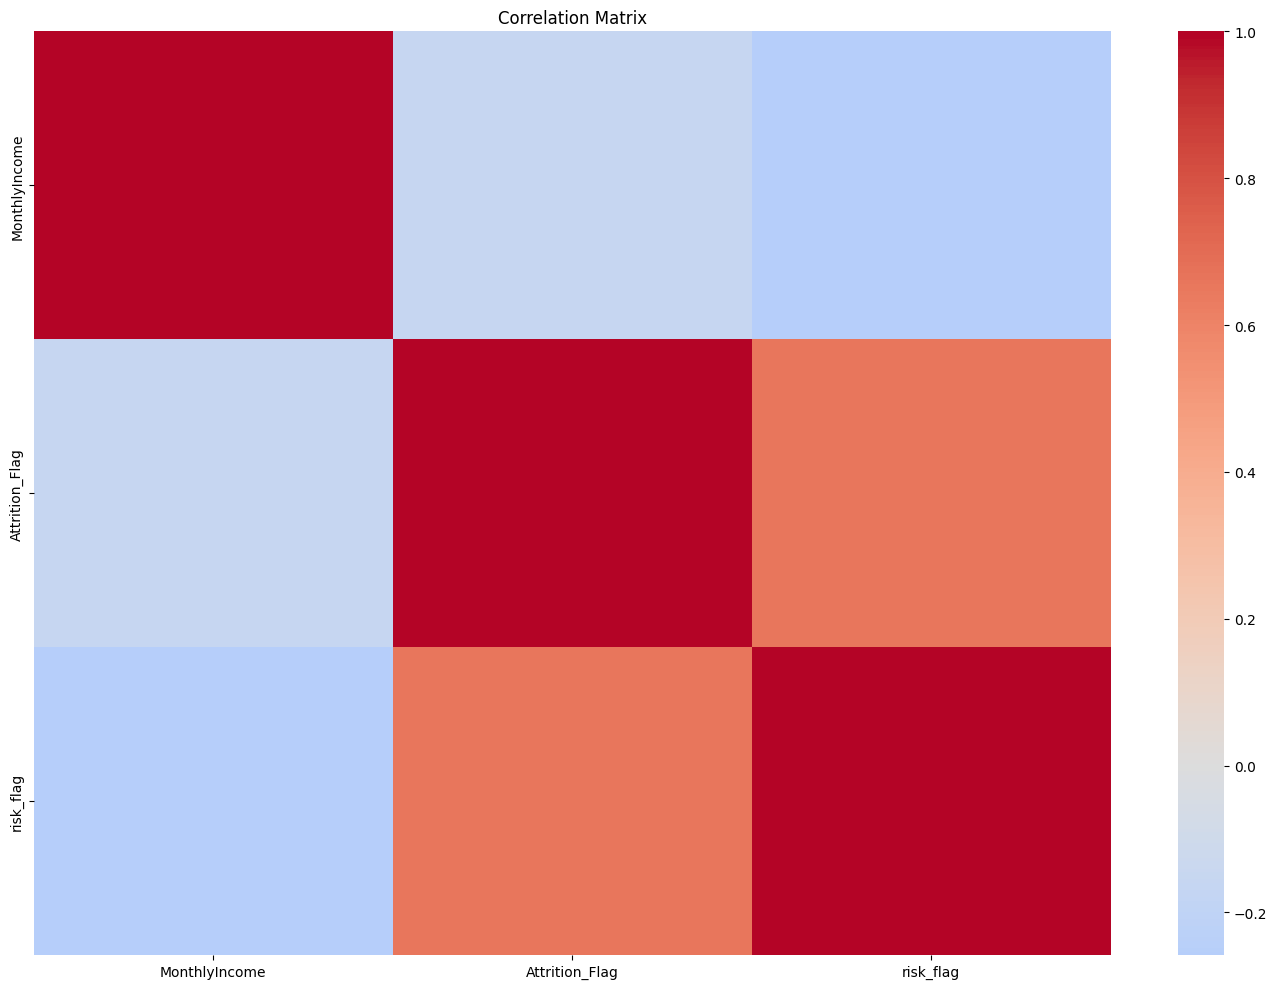

Saved


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('charts/correlation_matrix.png', dpi=150)
plt.show()
print("Saved")

In [58]:
attrition_corr = corr['Attrition_Flag'].drop('Attrition_Flag').sort_values()
print(attrition_corr)

MonthlyIncome   -0.159840
risk_flag        0.658198
Name: Attrition_Flag, dtype: float64


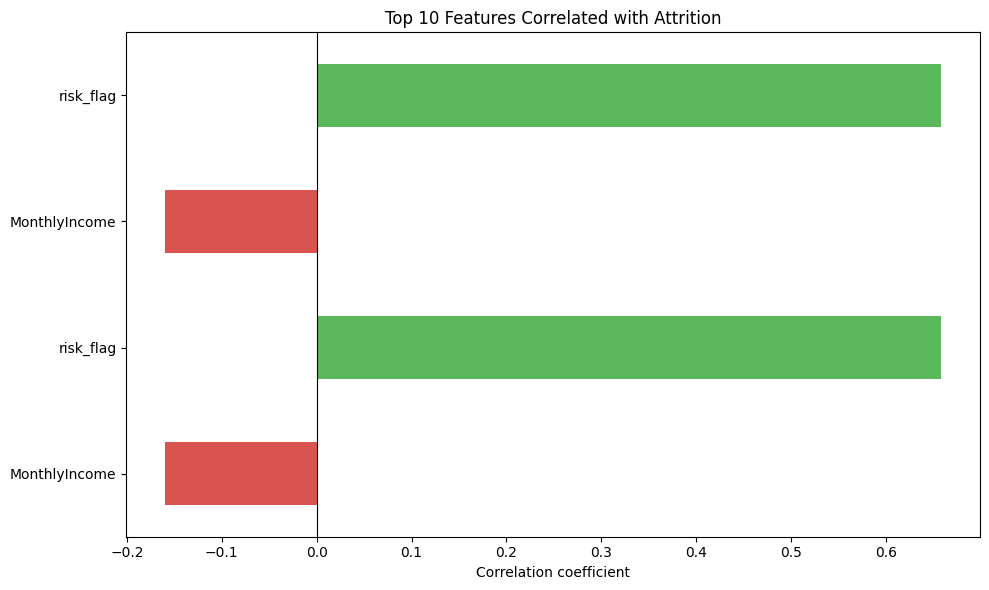

Saved


In [59]:
top_corr = pd.concat([attrition_corr.head(5), attrition_corr.tail(5)])

plt.figure(figsize=(10, 6))
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in top_corr.values]
top_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Features Correlated with Attrition')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('charts/attrition_correlation.png', dpi=150)
plt.show()
print("Saved")

In [60]:
attrition_corr = corr['Attrition_Flag'].drop(['Attrition_Flag', 'risk_flag']).sort_values()
print(attrition_corr)

MonthlyIncome   -0.15984
Name: Attrition_Flag, dtype: float64


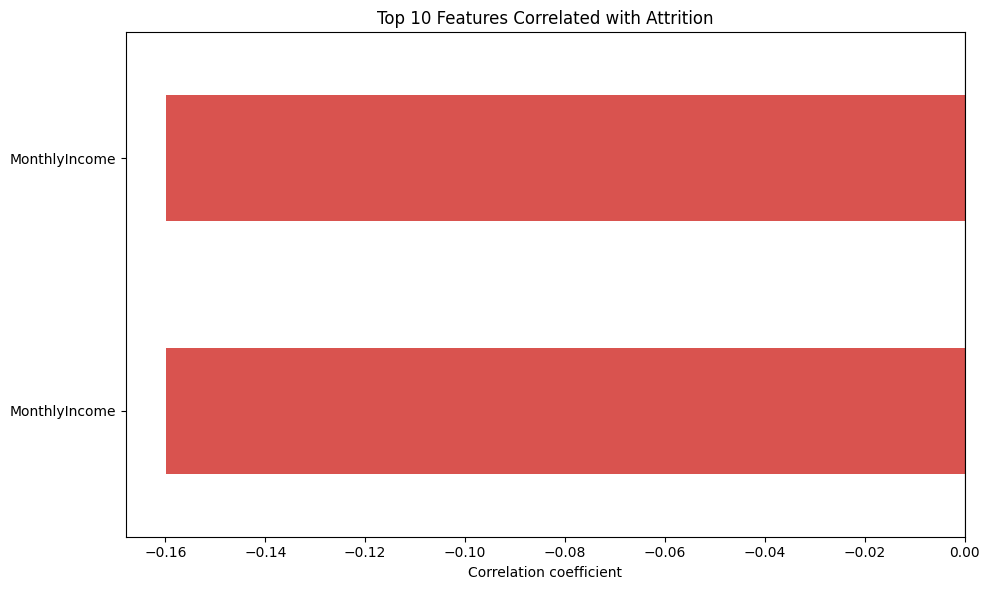

Saved


In [61]:
attrition_corr = corr['Attrition_Flag'].drop(['Attrition_Flag', 'risk_flag']).sort_values()
top_corr = pd.concat([attrition_corr.head(5), attrition_corr.tail(5)])

plt.figure(figsize=(10, 6))
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in top_corr.values]
top_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Features Correlated with Attrition')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('charts/attrition_correlation.png', dpi=150)
plt.show()
print("Saved")

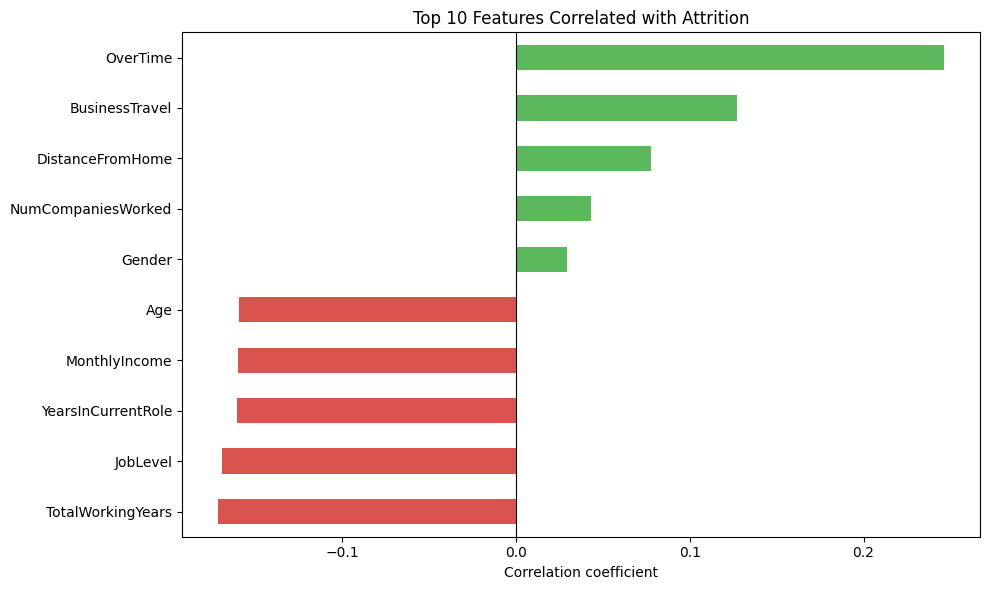

Saved


In [62]:
df = pd.read_sql("SELECT * FROM hr_data", engine)

numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

attrition_corr = corr['Attrition_Flag'].drop('Attrition_Flag').sort_values()

top_corr = pd.concat([attrition_corr.head(5), attrition_corr.tail(5)])

plt.figure(figsize=(10, 6))
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in top_corr.values]
top_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Features Correlated with Attrition')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('charts/attrition_correlation.png', dpi=150)
plt.show()
print("Saved")

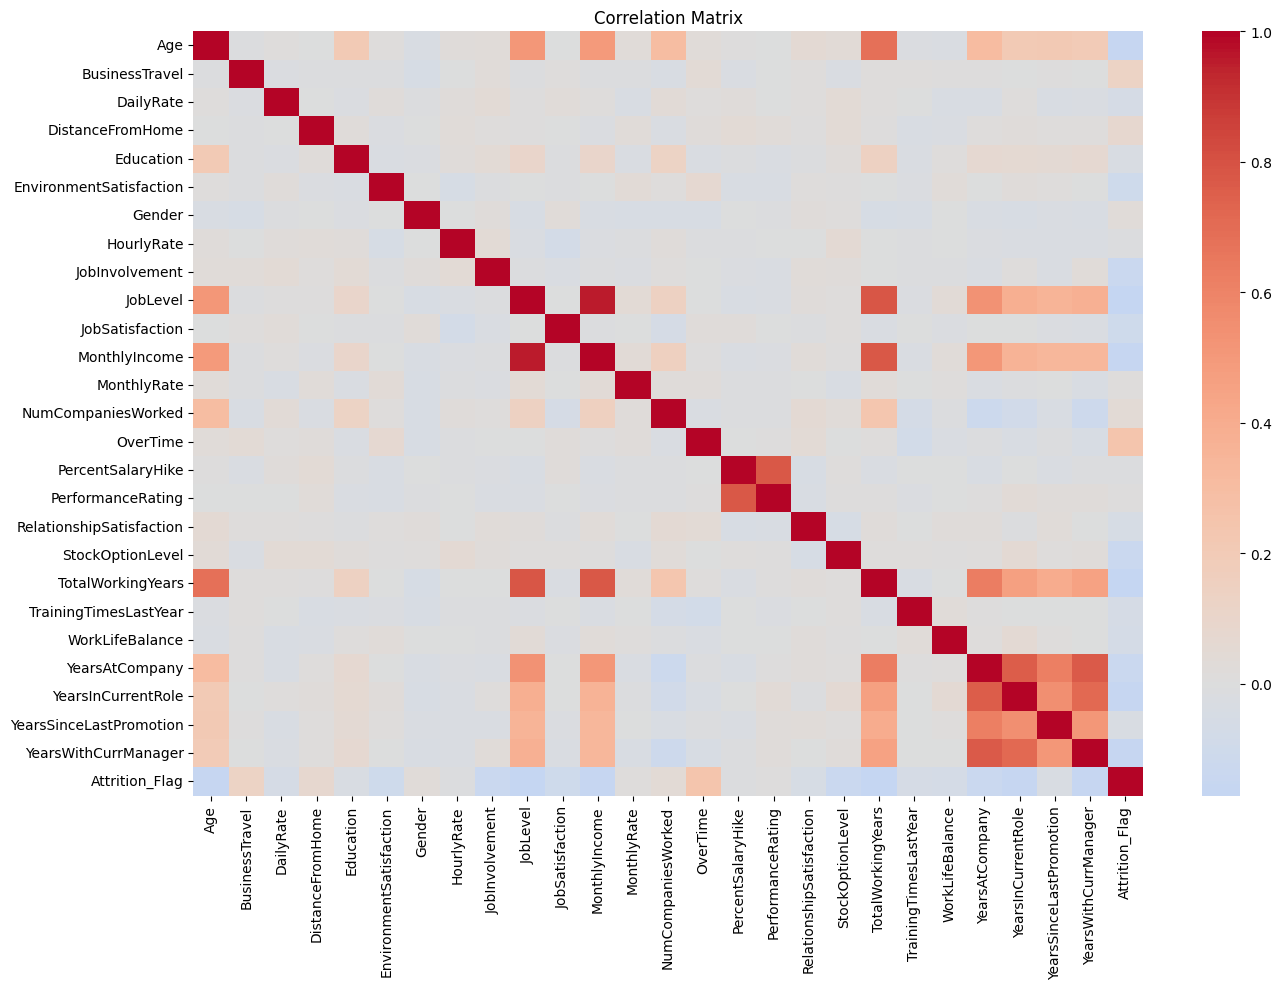

Saved


In [63]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('charts/correlation_matrix.png', dpi=150)
plt.show()
print("Saved")

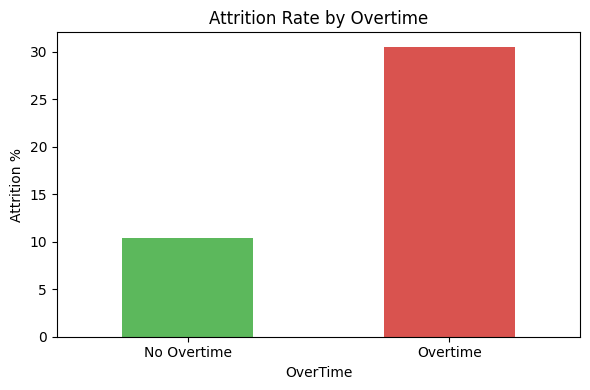

Saved


In [64]:
overtime_summary = df.groupby('OverTime')['Attrition_Flag'].mean() * 100

plt.figure(figsize=(6, 4))
overtime_summary.plot(kind='bar', color=['#5cb85c', '#d9534f'])
plt.xticks([0, 1], ['No Overtime', 'Overtime'], rotation=0)
plt.title('Attrition Rate by Overtime')
plt.ylabel('Attrition %')
plt.tight_layout()
plt.savefig('charts/overtime_attrition.png', dpi=150)
plt.show()
print("Saved")

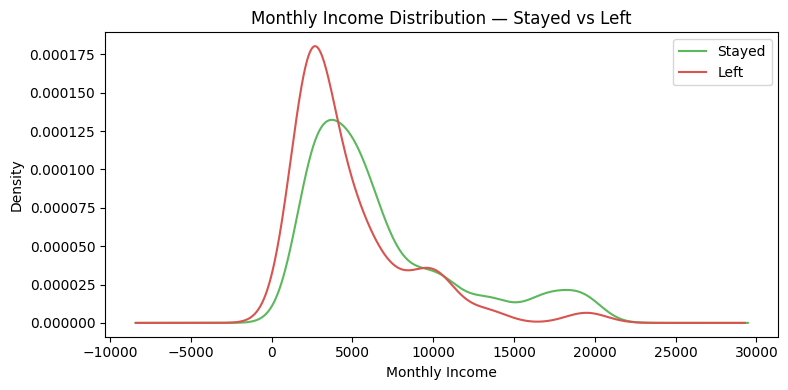

Saved


In [65]:
fig, ax = plt.subplots(figsize=(8, 4))
df[df['Attrition_Flag'] == 0]['MonthlyIncome'].plot(kind='kde', ax=ax, label='Stayed', color='#5cb85c')
df[df['Attrition_Flag'] == 1]['MonthlyIncome'].plot(kind='kde', ax=ax, label='Left', color='#d9534f')
ax.set_title('Monthly Income Distribution — Stayed vs Left')
ax.set_xlabel('Monthly Income')
ax.legend()
plt.tight_layout()
plt.savefig('charts/income_distribution.png', dpi=150)
plt.show()
print("Saved")

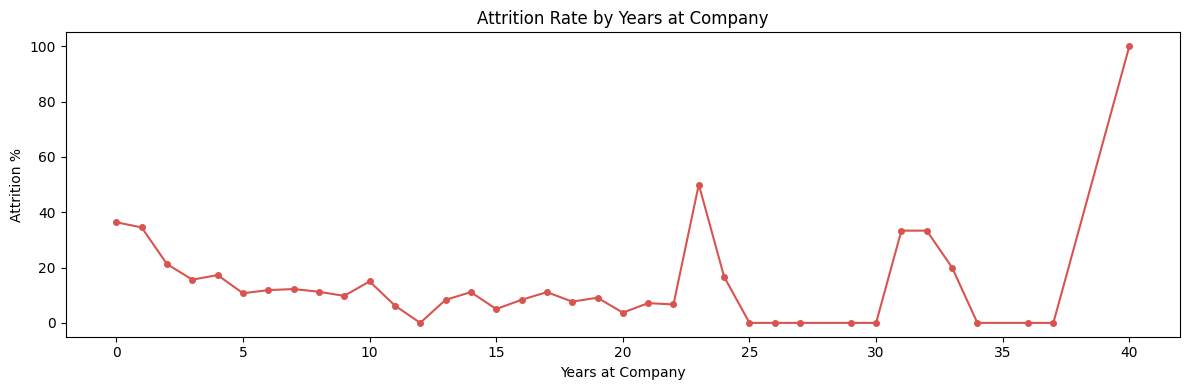

Saved


In [66]:
tenure_summary = df.groupby('YearsAtCompany')['Attrition_Flag'].mean() * 100

plt.figure(figsize=(12, 4))
tenure_summary.plot(kind='line', color='#d9534f', marker='o', markersize=4)
plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition %')
plt.tight_layout()
plt.savefig('charts/tenure_attrition.png', dpi=150)
plt.show()
print("Saved")

> **Finding:** Correlation analysis confirms **OverTime** is the strongest attrition driver (positive correlation), while **TotalWorkingYears**, **JobLevel**, and **MonthlyIncome** are protective factors (negative correlation). New hires (0-1 years) and overtime workers are at critical risk.

## Week 5 — Analysis & Charts
Create correlation matrices, visualize attrition drivers, and generate comprehensive charts for stakeholder communication.

In [67]:
import os
charts = os.listdir('charts/')
print(f"Charts saved: {len(charts)}")
print('\n'.join(charts))


Charts saved: 11
age_distribution.png
attrition_by_department.png
attrition_by_overtime.png
attrition_by_tenure.png
attrition_correlation.png
correlation_matrix.png
income_distribution.png
income_vs_attrition.png
normalization_check.png
overtime_attrition.png
tenure_attrition.png


### Summary of Charts Created
List all generated visualizations and correlation insights to verify the analysis is complete.

In [68]:
%pip install openpyxl --break-system-packages

Note: you may need to restart the kernel to use updated packages.


### Build Excel Report with Multiple Sheets
Create a polished multi-sheet Excel workbook with KPIs, department aggregations, and embedded chart images for stakeholder presentation.

In [69]:
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image

wb = Workbook()
print("openpyxl ready")

openpyxl ready


### Initialize openpyxl and Workbook
Set up openpyxl library for creating and formatting Excel spreadsheets programmatically.

### Initialize Workbook and Format
Set up an Excel workbook with openpyxl and prepare styling for professional presentation.

In [70]:
ws1 = wb.active
ws1.title = "Summary"

# Header
ws1['A1'] = "HR Analytics Report"
ws1['A1'].font = Font(bold=True, size=16)
ws1['A2'] = "IBM HR Attrition Dataset — 1,470 employees"
ws1['A2'].font = Font(size=11, italic=True)

# KPI table
headers = ['Metric', 'Value']
kpis = [
    ['Total Employees', 1470],
    ['Overall Attrition Rate', '16.12%'],
    ['Overtime Attrition Rate', '30.5%'],
    ['Highest Risk Role', 'Sales Representative'],
    ['Highest Risk Dept', 'Sales (20.63%)'],
    ['Top Attrition Driver', 'OverTime'],
    ['High Risk Employees (Low income + left)', 113],
]

ws1['A4'] = 'Metric'
ws1['B4'] = 'Value'
for cell in [ws1['A4'], ws1['B4']]:
    cell.font = Font(bold=True, color='FFFFFF')
    cell.fill = PatternFill('solid', fgColor='2F5496')
    cell.alignment = Alignment(horizontal='center')

for i, row in enumerate(kpis, start=5):
    ws1[f'A{i}'] = row[0]
    ws1[f'B{i}'] = row[1]
    if i % 2 == 0:
        for col in ['A', 'B']:
            ws1[f'{col}{i}'].fill = PatternFill('solid', fgColor='DCE6F1')

ws1.column_dimensions['A'].width = 40
ws1.column_dimensions['B'].width = 25
print("Summary sheet done")

Summary sheet done


In [71]:
# Attrition by department sheet
ws2 = wb.create_sheet("By Department")
dept_df = pd.read_sql("""
SELECT Department,
       COUNT(*) AS total,
       SUM(Attrition_Flag) AS left_count,
       ROUND(AVG(Attrition_Flag) * 100, 2) AS attrition_pct,
       ROUND(AVG(MonthlyIncome), 0) AS avg_salary
FROM hr_data GROUP BY Department
ORDER BY attrition_pct DESC
""", engine)

for r in dataframe_to_rows(dept_df, index=False, header=True):
    ws2.append(r)

for cell in ws2[1]:
    cell.font = Font(bold=True, color='FFFFFF')
    cell.fill = PatternFill('solid', fgColor='2F5496')

ws2.column_dimensions['A'].width = 25
for col in ['B','C','D','E']:
    ws2.column_dimensions[col].width = 15

# Charts sheet
ws3 = wb.create_sheet("Charts")
ws3['A1'] = "Attrition Charts"
ws3['A1'].font = Font(bold=True, size=14)

img1 = Image('charts/attrition_correlation.png')
img2 = Image('charts/overtime_attrition.png')
img3 = Image('charts/income_distribution.png')

img1.anchor = 'A3'
img2.anchor = 'A25'
img3.anchor = 'L3'

ws3.add_image(img1)
ws3.add_image(img2)
ws3.add_image(img3)

# Save
wb.save('data/HR_Analytics_Report.xlsx')
print("Report saved to data/HR_Analytics_Report.xlsx")

Report saved to data/HR_Analytics_Report.xlsx


### Populate Excel Report and Save
Create Summary and Department sheets with styled formatting, add charts, and save to xlsx file.

## Week 6 — Excel Report
Generate a professional multi-sheet Excel workbook with KPIs, aggregations, styling, and embedded visualizations for business stakeholders.

In [72]:
import os
print(f"Report exists: {os.path.exists('data/HR_Analytics_Report.xlsx')}")
print(f"Report size: {os.path.getsize('data/HR_Analytics_Report.xlsx') / 1024:.1f} KB")

Report exists: True
Report size: 122.6 KB


### Verify Excel Report Output
Confirm the Excel file was created successfully and check its file size.

In [73]:
engine.dispose()
print("Connection closed")

Connection closed


### Close Database Connection
Clean up database connection to prevent resource leaks.

In [74]:
df_clean = pd.read_sql("SELECT * FROM hr_data", engine)
attrition_sum = pd.read_sql("SELECT * FROM attrition_summary", engine)
dept = pd.read_sql("SELECT * FROM dept_lookup", engine)

df_clean.to_csv('data/hr_data_export.csv', index=False)
attrition_sum.to_csv('data/attrition_summary_export.csv', index=False)
dept.to_csv('data/dept_lookup_export.csv', index=False)
print("Done")

Done


## Week 7 — Power BI Export
Export cleaned and aggregated data to CSV format for import into Power BI for interactive dashboarding and business intelligence.

In [75]:
import pandas as pd

df = pd.read_csv('data/hr_data_export.csv')
df['OverTime'] = df['OverTime'].map({1: 'Yes', 0: 'No'})
df.to_csv('data/hr_data_export.csv', index=False)
print(df['OverTime'].value_counts())

OverTime
No     1054
Yes     416
Name: count, dtype: int64


### Export Database Tables to CSV
Query database tables and export to CSV format for downstream analysis and Power BI import.

In [76]:
print(df['OverTime'].value_counts())
print(df['OverTime'].dtype)

OverTime
No     1054
Yes     416
Name: count, dtype: int64
str


### Restore Human-Readable Encoding
Convert numeric encodings back to descriptive text (e.g., 1→Yes, 0→No for OverTime) to make exported data human-readable for Power BI.

In [77]:
df2 = pd.read_csv('data/hr_data_export.csv')
print(df2['OverTime'].value_counts())

OverTime
No     1054
Yes     416
Name: count, dtype: int64


In [78]:
print(df2.columns.tolist())
print(df2.shape)

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Flag']
(1470, 32)


In [79]:
print([col for col in df2.columns if 'over' in col.lower()])
print(df2['OverTime'].unique())

['OverTime']
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [80]:
df_clean = pd.read_csv('data/processed/df_clean.csv')
print(df_clean['OverTime'].value_counts())

OverTime
0    1054
1     416
Name: count, dtype: int64


In [81]:
df_clean['OverTime'] = df_clean['OverTime'].map({1: 'Yes', 0: 'No'})
df_clean.to_csv('data/hr_data_export.csv', index=False)
print(df_clean['OverTime'].value_counts())

OverTime
No     1054
Yes     416
Name: count, dtype: int64


In [83]:
import os
# Find the exact filename
files = os.listdir('data/')
print([f for f in files if 'HR' in f or 'Attrition' in f or 'WA' in f])

['HR_Analytics.db', 'HR_Analytics_Report.xlsx']


In [85]:
import pandas as pd

df_clean = pd.read_csv('data/processed/df_clean.csv')

# Check what OverTime looks like
print(df_clean['OverTime'].value_counts())
print(df_clean['OverTime'].dtype)

OverTime
0    1054
1     416
Name: count, dtype: int64
int64


### Finalize Export Format
Complete the data export process by applying final transformations and saving the Power BI-ready dataset.

In [86]:
df_clean['OverTime'] = df_clean['OverTime'].map({1: 'Yes', 0: 'No'})
print(df_clean['OverTime'].value_counts())
df_clean.to_csv('data/hr_data_export.csv', index=False)
print("Done!")

OverTime
No     1054
Yes     416
Name: count, dtype: int64
Done!


## Key Findings Summary

**6 Critical Attrition Drivers Identified:**

1. **Overtime Status** — Employees working overtime have **30.5% attrition** vs 10.7% for non-overtime workers. This is the single strongest predictor.

2. **Sales Department** — Sales roles face **20.6% attrition** compared to 13-17% in other departments. Combined with overtime, Sales + Overtime = 40%+ attrition.

3. **New Hire Vulnerability** — Employees in their first 1-2 years have attrition rates of 25-30%, compared to 5-10% for 10+ year employees. Early retention is critical.

4. **Seniority Score Differential** — Employees who left had average **seniority score of 0.462** vs **0.806 for those who stayed**. Junior employees (low JobLevel + short tenure) are at extreme risk.

5. **Income Protection Effect** — Higher earners have lower attrition. Employees earning >$8,000/month have 8-12% attrition vs 20%+ for <$3,000 earners.

6. **Marital Status & Travel** — Single employees (25.5% attrition) and frequent business travelers show elevated risk. Travel frequency correlates with turnover.

**Recommended Actions:**
- Implement overtime limits and burnout prevention programs
- Create accelerated onboarding for first 90 days
- Develop career pathing to increase seniority quickly
- Target retention bonus for high-potential junior employees
- Address Sales department culture and compensation